**Instructions:**

- Do not write your name on the assignment. Be careful about any warnings that might display some file path with your name included.
- Receiving help from classmates and/or ideas from Generative AI is allowed. **However, you must submit your own original work.**
- For questions that require coding, you need to write the relevant code and display its output. Your output should either be the direct answer to the question or clearly display the answer in it.
- For questions that require a written answer (sometimes along with the code), you need to put your answer in a Markdown cell. Writing the answer as a comment or as a print line is not acceptable.
- You need to render this file as HTML using Quarto and submit the HTML file. **Please note that this is a requirement and not optional.** A submission cannot be graded until it is properly rendered.

Import all the libraries and tools you need below.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

## 1)

Copy the `initialize`, `predict` and `calc_cost_gradient` functions you wrote in the two previous exercise sets here. **(1 point)**

In [46]:
def initialize(dim):
    return np.random.rand(dim + 1)

def predict(model_params, X_test):
    w_0 = model_params[0]
    w = model_params[1:]
    return w_0 + X_test @ w

def calc_cost_gradient(model_params, X_train, y_train):
    y_pred = predict(model_params, X_train)
    error = y_pred - y_train
    cost = np.mean(error ** 2)
    gradient = np.concatenate(([2 * np.mean(error)], (2 / len(y_train)) * X_train.T @ error))
    return cost, gradient

## 2)

Before completing and training the Linear Regression model, you need to preprocess the data you will use.

### a)

Read **Life_Exp_Data.csv**. The first column should be read as the index. Print the first 5 rows. **(2 points)**

Each observation represents a country and a year (e.g. U.S. in 2008). The task is to predict the `Life expectancy ` using all the other variables as features. 

In [47]:
df = pd.read_csv("Life_Exp_Data.csv", index_col=0)

df.head()

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,93.0,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,97.0,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### b)

Split the data into training and test sets with a 80%-20% ratio. Use `random_state=42` for reproducible results. 

Note that in order to create the training and test sets, you first need to separate the features and the response into two variables, so you can use them as proper inputs.

**(2 points)**

In [48]:
X = df.drop(columns=["Life expectancy "])
y = df["Life expectancy "]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### c)

(Standard) scale the training and test features. **(1 point)**

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3)

Using the sklearn object, create, train, and evaluate a Linear Regression model. Use Mean Absolute Error (MAE) as the evaluation metric. **Round the test MAE to 2 decimal places.** You can use the test MAE to check if your Gradient Descent algorithm runs correctly in the next question. **(4 points)**

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)

print(f"Test MAE: {round(test_mae, 2)}")

Test MAE: 2.71


## 4)

In this question, you will complete and run a custom Linear Regression model by training it with Gradient Descent.

### a)

Define a function called `GradientDescent`. This function will implement the Gradient Descent algorithm. It will do this by iteratively updating the input parameters by using the data, the learning rate and the `calc_cost_gradient` function. Please make sure you follow the equations for updating the parameters from the lectures.

The function should take five inputs: (1) `model_params`, which are the initial model parameters; (2) `X_train` and (3) `y_train`, which contain the training features and responses, respectively; (4) `lr`, which is the learning rate ($\eta$) in the Gradient Descent algorithm; and (5) `iters`, which is the number of iterations the Gradient Descent algorithm should run for.

The function should:

- Run the Gradient Descent algorithm.
- Print the minimized Mean Squared Error (MSE) cost.
- Display a line plot that shows how the cost changes through the iterations.
- Return one output, `model_params`, which contains the optimal model parameters. Note that you need to obtain this output by iteratively updating the input with the same name.

The Gradient Descent algorithm should run for as many iterations as given in `iters`. Note that this is not the most efficient implementation. This will be fixed in Homework Assignment 1.

**(50 points)**

In [51]:
def GradientDescent(model_params, X_train, y_train, lr, iters):
    costs = []

    for i in range(iters):
        cost, gradient = calc_cost_gradient(model_params, X_train, y_train)
        costs.append(cost)
        model_params = model_params - lr * gradient

    final_cost, _ = calc_cost_gradient(model_params, X_train, y_train)

    print("Final MSE:", final_cost)

    plt.plot(costs)
    plt.show()

    return model_params

### b)

Define a function called `linear_regression`. This is your actual custom model. The function body should include most functions you defined above.

The function should: 

- Take six inputs: `X_train`, `y_train`, `X_test`, `y_test`, `lr`, and `iters`, all of which should be self-explanatory at this point.
- Initialize the model parameters.
- Run the Gradient Descent algorithm to find the optimal parameters.
- Print the final (minimized) MSE cost and visualize how it changes through the iterations.
- Predict the test responses.
- Evaluate and print the test MAE, rounded to 2 decimal places.
- Return the optimal parameters.

**The entire function (including the definition and the return lines) should be written in 6 lines of code at most for credit.**

**(30 points)**

In [52]:
def linear_regression(X_train, y_train, X_test, y_test, lr, iters):
    model_params = initialize(X_train.shape[1])
    model_params = GradientDescent(model_params, X_train, y_train, lr, iters)
    print("Test MAE:", round(mean_absolute_error(y_test, predict(model_params, X_test)), 2))
    return model_params

### c)

Call the `linear_regression` function with the data preprocessed in Question 2. Experiment with the learning rate and the number of iterations to find reasonable values. You need to match the test MAE found in Question 3. **(10 points)**

Final MSE: 15.331578727392678


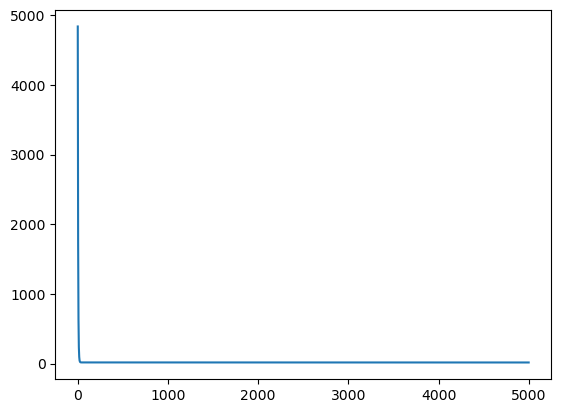

Test MAE: 2.71


In [ ]:
optimal_params = linear_regression(
    X_train, y_train, X_test, y_test,
    lr=0.06,
    iters=5000
)